In [249]:
from MyPlotRecipe.SharedX import ShareXaxis
from MyPlotRecipe.UniversalColor import UniversalColor
from MyPlotRecipe.legend_shadow import legend_shadow
import numpy as np
import math

from scipy import signal
import matplotlib.pyplot as plt
import matplotlib.ticker as ptick
from matplotlib.ticker import FixedLocator

import spiceypy as spice

from CSField import CSField
import JupiterMag as jm

jm.Internal.Config(Model='jrm33', CartesianIn=True,
                   CartesianOut=True)
jm.Con2020.Config(equation_type='integral')

UC = UniversalColor()
UC.set_palette()

spice.furnsh(
    '/Users/shin/Documents/Research/Jupiter/Codes/HST/kernel/cassMetaK.txt')

In [250]:
def day2hhmm(decimal_day):
    doy = int(decimal_day)
    rest = decimal_day - doy

    hours = int(rest*24)
    minutes = (rest*24-hours)*60

    if round(minutes) >= 60:
        hours += 1
        minutes = 0
    else:
        minutes = round(minutes)
    return hours, minutes


def hhmm2day(hours, minutes, seconds=0):
    fraction_of_day = hours/24 + minutes/(60*24) + seconds/(60*60*24)
    return fraction_of_day


def fmt_hhmm(decimal_day):
    hours, minutes = day2hhmm(decimal_day)
    hh = '{:02}'.format(hours)
    mm = '{:02}'.format(minutes)
    return hh+':'+mm

In [251]:
# 定数
RJ = 71492*1E+3  # Jupiter radius [m]
RE = 1560*1E+3   # Europa radius [m]
# Angular velocity of Jupiter System III rotation [rad sec-1]
OMG_J = 2*np.pi/(9.55*3600)
OMG_G = 2*np.pi/(7.2*24*3600)   # Ganymede orbital angular velosity [rad/sec]

Psyn_eu = (11.22)*3600      # Moon's synodic period [sec]
Psyn_ga = (10.53)*3600      # Moon's synodic period [sec]

In [252]:
PJ_num = 60

Bx, By, Bz = np.zeros(3), np.zeros(3), np.zeros(3)
time = np.zeros(3)
rx, ry, rz = np.zeros(3), np.zeros(3), np.zeros(3)
utc = []

filename = [
    'data/raw/fgm_jno_l3_2024097pc_r60s_v01.sts',
    'data/raw/fgm_jno_l3_2024098pc_r60s_v01.sts',
    'data/raw/fgm_jno_l3_2024099pc_r60s_v01.sts',
    'data/raw/fgm_jno_l3_2024100pc_pj60_r60s_v02.sts',
    'data/raw/fgm_jno_l3_2024100pc_r60s_v02.sts',
    'data/raw/fgm_jno_l3_2024101pc_r60s_v01.sts',
    'data/raw/fgm_jno_l3_2024102pc_r60s_v01.sts',
    'data/raw/fgm_jno_l3_2024103pc_r60s_v01.sts',
    # 'data/raw/fgm_jno_l3_2024104pc_r60s_v01.sts',
]

dir = '/Users/shin/Documents/Research/Juno/Mag/Codes/'
for i in range(len(filename)):
    f = np.loadtxt(dir+'/'+filename[i], skiprows=126)
    Bx = np.append(Bx, f[:, 7])
    By = np.append(By, f[:, 8])
    Bz = np.append(Bz, f[:, 9])
    rx = np.append(rx, f[:, 11])     # [km]
    ry = np.append(ry, f[:, 12])     # [km]
    rz = np.append(rz, f[:, 13])     # [km]
    time = np.append(time, f[:, 6])  # [day]
    # if i > 5:
    #     time = np.append(time, f[:, 6]+365.0)  # PJ31 [day]
    # else:
    #     time = np.append(time, f[:, 6])  # PJ31 [day]
    for j in range(f[:, 0].size):
        utc += [str(int(f[j, 0]))+'-'+str(int(f[j, 1]))+'T'+str(int(f[j, 2])
                                                                ).zfill(2)+':'+str(int(f[j, 3])).zfill(2)+':'+str(int(f[j, 4])).zfill(2)]

Bx, By, Bz = Bx[3:], By[3:], Bz[3:]
time = time[3:]
rx, ry, rz = rx[3:], ry[3:], rz[3:]

time_argsort = np.argsort(time)
Bx, By, Bz = Bx[time_argsort], By[time_argsort], Bz[time_argsort]
rx, ry, rz = rx[time_argsort], ry[time_argsort], rz[time_argsort]
time = time[time_argsort]
print(time[0], fmt_hhmm(time[0]))
print(time[-1], fmt_hhmm(time[-1]))
print(utc)
print(len(utc), time.size)
print('r_start: ', np.sqrt(rx[0]**2+ry[0]**2+rz[0]**2)/71492.0)
print('r_end:', np.sqrt(rx[-1]**2+ry[-1]**2+rz[-1]**2)/71492.0)

97.008680862 00:13
103.999663895 24:00
['2024-97T00:12:30', '2024-97T00:13:30', '2024-97T00:14:30', '2024-97T00:15:30', '2024-97T00:16:30', '2024-97T00:17:30', '2024-97T00:18:30', '2024-97T00:19:30', '2024-97T00:20:30', '2024-97T00:21:30', '2024-97T00:22:30', '2024-97T00:23:30', '2024-97T00:24:30', '2024-97T00:25:30', '2024-97T00:26:30', '2024-97T00:27:30', '2024-97T00:28:30', '2024-97T00:29:30', '2024-97T00:30:30', '2024-97T00:31:30', '2024-97T00:32:30', '2024-97T00:33:30', '2024-97T00:34:30', '2024-97T00:35:30', '2024-97T00:36:30', '2024-97T00:37:30', '2024-97T00:38:30', '2024-97T00:39:30', '2024-97T00:40:30', '2024-97T00:41:30', '2024-97T00:42:30', '2024-97T00:43:30', '2024-97T00:44:30', '2024-97T00:45:30', '2024-97T00:46:30', '2024-97T00:47:30', '2024-97T00:48:30', '2024-97T00:49:30', '2024-97T00:50:30', '2024-97T00:51:30', '2024-97T00:52:30', '2024-97T00:53:30', '2024-97T00:54:30', '2024-97T00:55:30', '2024-97T00:56:30', '2024-97T00:57:30', '2024-97T00:58:30', '2024-97T00:59:30', 

In [253]:
# Juno探査機のMLTを計算
MLT = np.zeros(len(utc))
for j in range(len(utc)):
    # Jupiterから見たJunoの位置
    r_juno, _ = spice.spkpos(
        "JUNO",
        spice.utc2et(utc[j]),
        "IAU_JUPITER",
        "NONE",
        "JUPITER"
    )

    R = spice.pxform(
        "IAU_JUPITER",
        "JUNO_JSO",
        spice.utc2et(utc[j])
    )
    r_jso = R @ r_juno

    x_jso, y_jso, z_jso = r_jso
    phi = np.arctan2(y_jso, x_jso)
    phi = np.mod(phi, 2*np.pi)
    MLT[j] = (12.0 + phi / (2*np.pi) * 24.0) % 24.0

9960 9960


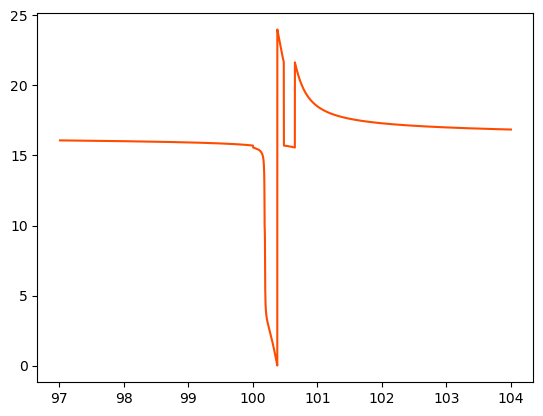

In [254]:
plt.plot(time, MLT)
print(MLT.size, rx.size)

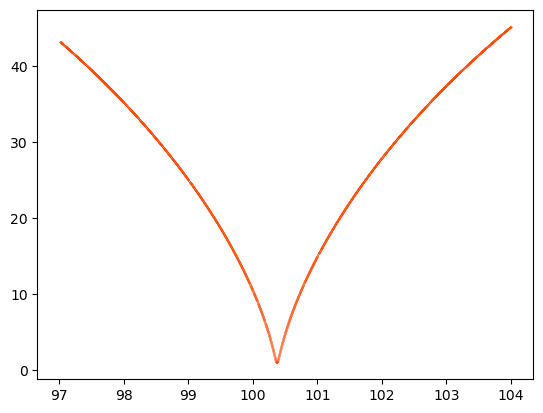

In [255]:
plt.scatter(time, np.sqrt(rx**2+ry**2+rz**2)/71492, s=0.005)

In [256]:
print(1/((time[2]-time[1])*60*60*24),  'Hz')

0.016666677333242515 Hz


In [257]:
f_resample = (1/(60*2))       # [Hz]
T_resample = 1/f_resample   # [sec]
t0 = time[1]        # obs. start time [sec]
t1 = time[-1]       # obs. end time [sec]

print(t0, t1)
print(t0+T_resample)

97.009375307 103.999663895
217.009375307


In [258]:
# 新しい時間軸
time_arr = np.arange(t0, t1, T_resample/(60*60*24))
print(time_arr.shape)
print(time_arr[0])

(5034,)
97.009375307


In [259]:
# リサンプル
Bx_re = np.zeros(time_arr.shape)
By_re = np.zeros(time_arr.shape)
Bz_re = np.zeros(time_arr.shape)
rx_re = np.zeros(time_arr.shape)
ry_re = np.zeros(time_arr.shape)
rz_re = np.zeros(time_arr.shape)
MLT_re = np.zeros(time_arr.shape)
time_sec = time*60*60*24                # 元データの時間軸
time_sec_re = time_arr*60*60*24        # 新しい時間軸

# np.interpを使ってリサンプリングしてみる (線形補間)
Bx_re = np.interp(time_sec_re, time_sec, Bx)
By_re = np.interp(time_sec_re, time_sec, By)
Bz_re = np.interp(time_sec_re, time_sec, Bz)
rx_re = np.interp(time_sec_re, time_sec, rx)
ry_re = np.interp(time_sec_re, time_sec, ry)
rz_re = np.interp(time_sec_re, time_sec, rz)
MLT_re = np.interp(time_sec_re, time_sec, MLT)

In [260]:
def downsample_skip_gaps(t_orig, y_orig, dt=120, max_gap=150):
    """
    t_orig : 元データの時刻配列 (秒単位)
    y_orig : 元データの値配列
    dt     : ダウンサンプリング周期 (1/120 Hz なら 120秒)
    max_gap: 許容する最大欠損時間 (例: 180秒)
    """
    # 1. 時間間隔が max_gap を超える位置（欠損発生位置）を特定
    gap_indices = np.where(np.diff(t_orig) > max_gap)[0] + 1

    # 2. 欠損位置で元データを複数の連続ブロックに分割
    t_chunks = np.split(t_orig, gap_indices)
    y_chunks = np.split(y_orig, gap_indices)

    t_res = []
    y_res = []

    for t_c, y_c in zip(t_chunks, y_chunks):
        # 補間には最低2点以上が必要
        if len(t_c) < 2:
            continue

        # 3. グローバルな120秒刻み (dt) の位相を揃えた時刻グリッドを生成
        t_start = np.ceil(t_c[0] / dt) * dt
        t_end = t_c[-1]

        # このブロック内にダウンサンプリング対象の時刻が含まれない場合はスキップ
        if t_start > t_end:
            continue

        t_new_chunk = np.arange(t_start, t_end + 1e-9, dt)

        # 4. 区間内のみで線形補間（欠損区間を跨がない）
        y_new_chunk = np.interp(t_new_chunk, t_c, y_c)

        t_res.append(t_new_chunk)
        y_res.append(y_new_chunk)

    if not t_res:
        return np.array([]), np.array([])

    # 5. 有効区間の結果のみを連結
    return np.concatenate(t_res), np.concatenate(y_res)


# 使用例 (120秒刻み、180秒以上の欠損はすっ飛ばす)
time_sec_re, rx_re = downsample_skip_gaps(time_sec, rx, dt=120, max_gap=160)
time_sec_re, ry_re = downsample_skip_gaps(time_sec, ry, dt=120, max_gap=160)
time_sec_re, rz_re = downsample_skip_gaps(time_sec, rz, dt=120, max_gap=160)
time_sec_re, Bx_re = downsample_skip_gaps(time_sec, Bx, dt=120, max_gap=160)
time_sec_re, By_re = downsample_skip_gaps(time_sec, By, dt=120, max_gap=160)
time_sec_re, Bz_re = downsample_skip_gaps(time_sec, Bz, dt=120, max_gap=160)
time_sec_re, MLT_re = downsample_skip_gaps(time_sec, MLT, dt=120, max_gap=160)

In [261]:
savedir = 'data/FGM/PJ'+str(int(PJ_num)).zfill(2)+'/'
np.savetxt(
    savedir+'fgm_PJ'+str(int(PJ_num)).zfill(2)+'_pc_2min_Bx.txt', Bx_re)
np.savetxt(
    savedir+'fgm_PJ'+str(int(PJ_num)).zfill(2)+'_pc_2min_By.txt', By_re)
np.savetxt(
    savedir+'fgm_PJ'+str(int(PJ_num)).zfill(2)+'_pc_2min_Bz.txt', Bz_re)
np.savetxt(
    savedir+'fgm_PJ'+str(int(PJ_num)).zfill(2)+'_pc_2min_rx.txt', rx_re)
np.savetxt(
    savedir+'fgm_PJ'+str(int(PJ_num)).zfill(2)+'_pc_2min_ry.txt', ry_re)
np.savetxt(
    savedir+'fgm_PJ'+str(int(PJ_num)).zfill(2)+'_pc_2min_rz.txt', rz_re)
np.savetxt(
    savedir+'fgm_PJ'+str(int(PJ_num)).zfill(2)+'_pc_2min_time.txt', time_sec_re)
np.savetxt(
    savedir+'fgm_PJ'+str(int(PJ_num)).zfill(2)+'_pc_2min_JunoMLT.txt', MLT_re)